# Lab: Phân lớp ảnh CIFAR-10 bằng CNN trên Google Colab

## Step 0 — Bật GPU

In [3]:
import os, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


## Step 1 — Cài & nhập thư viện, cố định seed

In [4]:
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: []


## Step 2 — Lấy 300 ảnh CIFAR-10 (30 ảnh mỗi lớp) và chia 80/20

In [5]:
# 1) Tải CIFAR-10 (60k ảnh 32x32x3, 10 lớp)
(x_tr0, y_tr0), (x_te0, y_te0) = keras.datasets.cifar10.load_data()
X_all = np.concatenate([x_tr0, x_te0], axis=0)
y_all = np.concatenate([y_tr0, y_te0], axis=0).ravel()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# 2) Lấy ít dữ liệu để chạy nhanh: 30 ảnh cho mỗi lớp -> tổng 300 ảnh
NUM_PER_CLASS = 30  # bạn có thể giảm còn 20 cho siêu nhanh
Xs, ys = [], []
for c in range(10):
    idx = np.where(y_all==c)[0]
    pick = np.random.choice(idx, size=NUM_PER_CLASS, replace=False)
    Xs.append(X_all[pick])
    ys.append(y_all[pick])
X_small = np.concatenate(Xs, axis=0)
y_small = np.concatenate(ys, axis=0)

# 3) Trộn & chia 80/20 giữ tỉ lệ lớp
perm = np.random.permutation(len(X_small))
X_small, y_small = X_small[perm], y_small[perm]

X_train, X_test, y_train, y_test = train_test_split(
    X_small, y_small, test_size=0.2, random_state=42, stratify=y_small
)

print("Train:", X_train.shape, "Test:", X_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 673s 4us/step
Train: (240, 32, 32, 3) Test: (60, 32, 32, 3)


## Step 3 — Tiền xử lý & xem nhanh vài ảnh

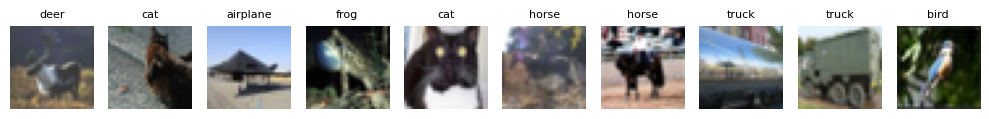

In [6]:
# Chuẩn hoá pixel về [0,1] (giúp học ổn định hơn)
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32")  / 255.0

# One-hot cho nhãn
num_classes = 10
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes)

# Xem 10 ảnh đầu tiên
plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(X_train[i])
    plt.axis('off')
    plt.title(class_names[y_train[i]], fontsize=8)
plt.tight_layout(); plt.show()


## Step 4 — Xây CNN nhỏ gọn (chạy nhanh)

In [7]:
def build_small_cnn(input_shape=(32,32,3), num_classes=10):
    inp = keras.Input(shape=input_shape, name="input")

    # Block 1: 2 conv (32 filters) + maxpool
    x = layers.Conv2D(32, 3, padding="same", activation="relu", name="block1_conv1")(inp)
    x = layers.Conv2D(32, 3, padding="same", activation="relu", name="block1_conv2")(x)
    x = layers.MaxPooling2D(2, name="block1_pool")(x)

    # Block 2: 2 conv (64 filters) + maxpool
    x = layers.Conv2D(64, 3, padding="same", activation="relu", name="block2_conv1")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu", name="block2_conv2")(x)
    x = layers.MaxPooling2D(2, name="block2_pool")(x)

    # Classifier
    x = layers.Flatten(name="flatten")(x)
    x = layers.Dense(128, activation="relu", name="fc")(x)
    x = layers.Dropout(0.3)(x)  # chút regularization
    out = layers.Dense(num_classes, activation="softmax", name="pred")(x)

    return keras.Model(inp, out, name="small_cnn")

model = build_small_cnn(input_shape=X_train.shape[1:], num_classes=num_classes)
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="categorical_crossentropy",
              metrics=["accuracy"])
model.summary()


Model: "small_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc (Dense)                      │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,274 (2.26 MB)

 Trainable params: 591,274 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

## Step 5 — Huấn luyện nhanh (chỉ 5 epoch)

In [8]:
EPOCHS = 5
history = model.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=32,
    verbose=1
)


Epoch 1/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 222ms/step - accuracy: 0.0677 - loss: 2.3357 - val_accuracy: 0.0833 - val_loss: 2.3197
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - accuracy: 0.1250 - loss: 2.2874 - val_accuracy: 0.0208 - val_loss: 2.3446
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - accuracy: 0.1198 - loss: 2.2797 - val_accuracy: 0.0208 - val_loss: 2.3358
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.1562 - loss: 2.2412 - val_accuracy: 0.0208 - val_loss: 2.3198
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.1354 - loss: 2.2274 - val_accuracy: 0.1042 - val_loss: 2.2431


## Step 6 — Đánh giá & báo cáo ngắn

In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
print(classification_report(y_test, y_pred, target_names=class_names))


Test accuracy: 0.2167
              precision    recall  f1-score   support

    airplane       0.25      0.50      0.33         6
  automobile       0.33      0.83      0.48         6
        bird       0.00      0.00      0.00         6
         cat       0.00      0.00      0.00         6
        deer       0.00      0.00      0.00         6
         dog       0.00      0.00      0.00         6
        frog       0.00      0.00      0.00         6
       horse       0.15      0.83      0.26         6
        ship       0.00      0.00      0.00         6
       truck       0.00      0.00      0.00         6

    accuracy                           0.22        60
   macro avg       0.07      0.22      0.11        60
weighted avg       0.07      0.22      0.11        60



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Step 7 — Trực quan Kernels (bộ lọc) của conv đầu tiên

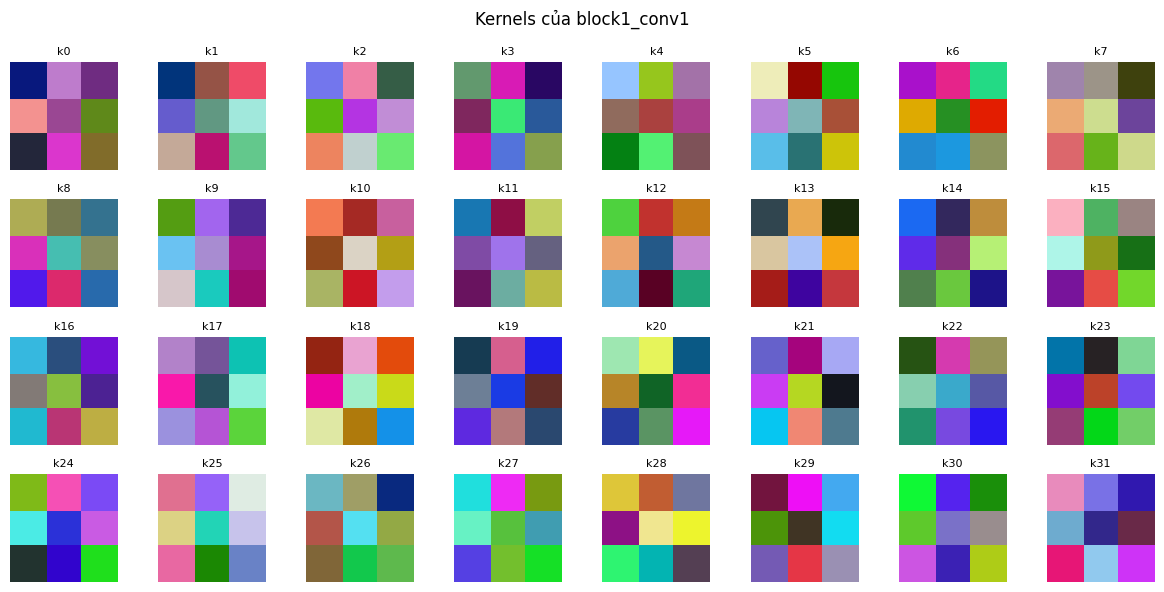

In [10]:
# Lấy trọng số (weights) của lớp conv đầu tiên: shape (kh, kw, in_ch, out_ch)
first_conv = model.get_layer("block1_conv1")
weights, biases = first_conv.get_weights()  # weights: (3,3,3,32)

# Chuẩn hoá từng kernel về [0,1] để hiển thị đẹp
w = weights.copy()
w_min, w_max = w.min(), w.max()
w = (w - w_min) / (w_max - w_min + 1e-8)

num_filters = w.shape[-1]
n_cols = 8
n_rows = int(np.ceil(num_filters / n_cols))

plt.figure(figsize=(n_cols*1.5, n_rows*1.5))
for i in range(num_filters):
    f = w[:,:,:,i]  # kernel 3x3x3
    # Phóng to kernel lên 32x32 để nhìn rõ (resize nearest-neighbor)
    vis = tf.image.resize(f[np.newaxis, ...], (32,32), method="nearest")[0].numpy()
    plt.subplot(n_rows, n_cols, i+1)
    plt.imshow(vis)   # hiển thị như 1 ảnh RGB nhỏ
    plt.axis("off")
    plt.title(f"k{i}", fontsize=8)
plt.suptitle("Kernels của block1_conv1"); plt.tight_layout(); plt.show()


## Step 8 — Trực quan Feature Maps sau từng lớp conv

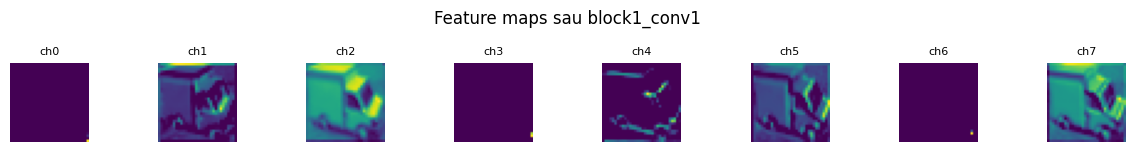

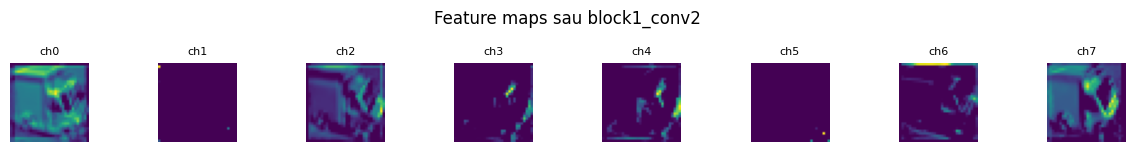

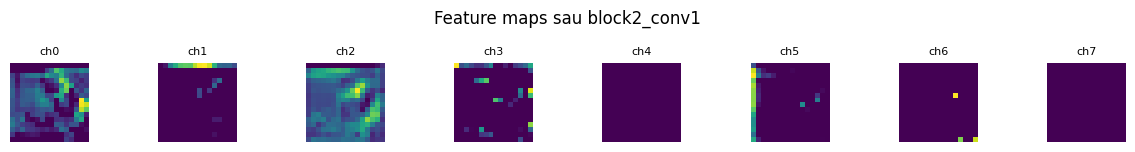

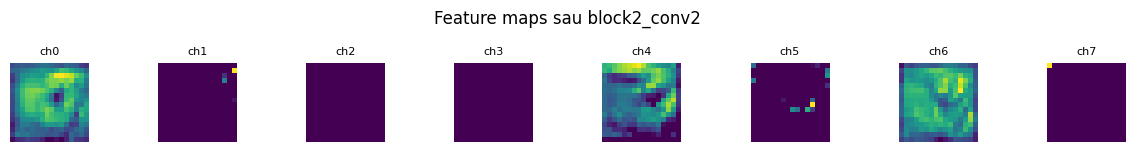

In [11]:
# Chọn 1 ảnh mẫu từ test để quan sát dòng chảy đặc trưng
sample = X_test[0][np.newaxis, ...]  # shape (1,32,32,3)

# Tạo "mô hình trung gian" trả về đầu ra của các lớp conv
conv_layers = ["block1_conv1","block1_conv2","block2_conv1","block2_conv2"]
intermediate_model = keras.Model(
    inputs=model.input,
    outputs=[model.get_layer(n).output for n in conv_layers]
)
feature_maps = intermediate_model.predict(sample, verbose=0)

def show_feature_maps(fmap, title, max_channels=8):
    """
    fmap: tensor (1,H,W,C). Hàm sẽ hiển thị tối đa max_channels kênh đặc trưng.
    """
    fmap = fmap[0]  # (H,W,C)
    c = min(fmap.shape[-1], max_channels)
    plt.figure(figsize=(c*1.5, 1.5))
    for i in range(c):
        plt.subplot(1, c, i+1)
        ch = fmap[:,:,i]
        # Chuẩn hoá kênh về [0,1] để hiển thị rõ
        ch_min, ch_max = ch.min(), ch.max()
        ch = (ch - ch_min) / (ch_max - ch_min + 1e-8)
        plt.imshow(ch, cmap="viridis")
        plt.axis("off")
        plt.title(f"ch{i}", fontsize=8)
    plt.suptitle(title); plt.tight_layout(); plt.show()

# Hiển thị maps sau từng lớp conv (chỉ 8 kênh đầu để nhìn nhanh)
for name, fmap in zip(conv_layers, feature_maps):
    show_feature_maps(fmap, f"Feature maps sau {name}", max_channels=8)


## Step 9 — Dự đoán nhanh 12 ảnh và gắn ✓/✗

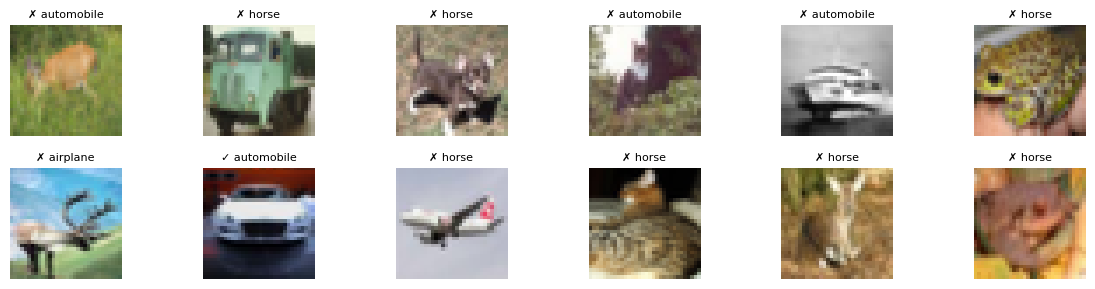

In [13]:
idx = np.random.choice(len(X_test), size=12, replace=False)
images, labels = X_test[idx], y_test[idx]
preds = model.predict(images, verbose=0).argmax(axis=1)

plt.figure(figsize=(12,3))
for i in range(12):
    plt.subplot(2,6,i+1)
    plt.imshow(images[i])
    plt.axis('off')
    ok = "✓" if labels[i]==preds[i] else "✗"
    plt.title(f"{ok} {class_names[preds[i]]}", fontsize=8)
plt.tight_layout(); plt.show()